In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              ExtraTreesRegressor, AdaBoostRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

BATTERY_CAPACITY_KWH = 33.0  # BMW i3 (60 Ah) usable capacity

In [44]:
# Load all trips — keep all columns, use pattern matching to find them
# (avoids encoding issues with ° character across trip files)
trip_files = sorted(glob('BMW_i3_Dataset/Trip*.csv'))

def find_col(columns, pattern):
    """Find first column containing pattern (case-insensitive)."""
    for c in columns:
        if pattern.lower() in c.lower():
            return c
    return None

valid_trips = []
for f in trip_files:
    df = pd.read_csv(f, sep=';', encoding='latin-1')
    
    # Verify essential columns exist
    soc_col = find_col(df.columns, 'SoC')
    vel_col = find_col(df.columns, 'Velocity')
    if not soc_col or not vel_col:
        continue
    
    soc_change = df[soc_col].iloc[0] - df[soc_col].iloc[-1]
    if soc_change > 2:  # lowered from 5 — include shorter trips
        trip_name = f.replace('\\', '/').split('/')[-1]
        valid_trips.append((trip_name, df, soc_change))

print(f"Loaded {len(valid_trips)} valid trips out of {len(trip_files)} total")
for name, df, dSOC in valid_trips:
    season = 'Summer' if 'TripA' in name else 'Winter'
    vel_col = find_col(df.columns, 'Velocity')
    dist_km = (df[vel_col] / 3600 * 0.1).sum()
    print(f"  {name}: ΔSOC={dSOC:.1f}%, {df['Time [s]'].max()/60:.0f}min, ~{dist_km:.1f}km, {season}")

Loaded 42 valid trips out of 70 total
  TripA01.csv: ΔSOC=5.4%, 17min, ~7.4km, Summer
  TripA02.csv: ΔSOC=13.0%, 24min, ~23.5km, Summer
  TripA03.csv: ΔSOC=8.4%, 11min, ~12.8km, Summer
  TripA04.csv: ΔSOC=8.4%, 7min, ~10.7km, Summer
  TripA05.csv: ΔSOC=6.5%, 23min, ~12.4km, Summer
  TripA06.csv: ΔSOC=21.7%, 53min, ~46.0km, Summer
  TripA07.csv: ΔSOC=29.2%, 35min, ~44.3km, Summer
  TripA08.csv: ΔSOC=10.5%, 47min, ~18.2km, Summer
  TripA09.csv: ΔSOC=6.1%, 31min, ~11.7km, Summer
  TripA10.csv: ΔSOC=8.7%, 24min, ~16.2km, Summer
  TripA11.csv: ΔSOC=11.4%, 24min, ~17.7km, Summer
  TripA12.csv: ΔSOC=11.2%, 27min, ~18.7km, Summer
  TripA13.csv: ΔSOC=2.9%, 12min, ~4.6km, Summer
  TripA14.csv: ΔSOC=2.9%, 12min, ~4.9km, Summer
  TripA15.csv: ΔSOC=11.4%, 37min, ~27.0km, Summer
  TripA16.csv: ΔSOC=16.2%, 32min, ~28.8km, Summer
  TripA17.csv: ΔSOC=8.9%, 11min, ~13.0km, Summer
  TripA18.csv: ΔSOC=7.7%, 15min, ~12.2km, Summer
  TripA19.csv: ΔSOC=8.1%, 26min, ~16.7km, Summer
  TripA20.csv: ΔSOC=7.9%, 2

In [45]:
# Build windowed segments from each trip
# Target: energy consumption rate (Wh/km) — range = remaining_energy / consumption_rate
# Ground truth energy from SOC delta (more reliable than V*I which has sign/regen issues)
#
# KEY CHANGE: WINDOW=600 (~60s) instead of 300 (~30s)
# Larger windows → bigger SOC delta → less quantization noise in the target
WINDOW = 600   # samples (~60 seconds at 10Hz)
STRIDE = 200   # ~33% overlap — still plenty of segments
MIN_SPEED = 3  # km/h — skip stationary
MIN_DIST = 0.2 # km — minimum window distance (raised for longer windows)

segments = []
for trip_name, df, _ in valid_trips:
    # Map columns using pattern matching (handles encoding differences)
    cols = {}
    col_patterns = {
        'vel': 'Velocity', 'elev': 'Elevation', 'throttle': 'Throttle',
        'torque': 'Motor Torque', 'accel': 'Longitudinal Acceleration',
        'regen': 'Regenerative Braking', 'volt': 'Battery Voltage',
        'curr': 'Battery Current', 'btemp': 'Battery Temperature',
        'soc': 'SoC', 'heat': 'Heating Power CAN', 'ac': 'AirCon Power',
        'atemp': 'Ambient Temperature'
    }
    for key, pattern in col_patterns.items():
        matches = [c for c in df.columns if pattern in c
                   and 'displayed' not in c and 'min.' not in c.lower()
                   and 'max.' not in c.lower()]
        if matches:
            cols[key] = matches[0]
    
    if 'vel' not in cols or 'soc' not in cols or 'volt' not in cols:
        continue
    
    # Filter to moving samples
    mask = df[cols['vel']] > MIN_SPEED
    dfm = df[mask].reset_index(drop=True)
    if len(dfm) < WINDOW + STRIDE:
        continue
    
    is_winter = 1 if 'TripB' in trip_name else 0
    
    # Precompute time deltas and distances
    dt = dfm['Time [s]'].diff().clip(0.01, 1.0).fillna(0.1)
    dist_km = (dfm[cols['vel']] / 3600) * dt
    
    for i in range(0, len(dfm) - WINDOW, STRIDE):
        w = dfm.iloc[i:i+WINDOW]
        w_dt = dt.iloc[i:i+WINDOW]
        w_dist = dist_km.iloc[i:i+WINDOW]
        
        total_dist = w_dist.sum()
        if total_dist < MIN_DIST:
            continue
        
        # Ground truth energy from SOC delta
        soc_start = w[cols['soc']].iloc[0]
        soc_end = w[cols['soc']].iloc[-1]
        soc_delta = soc_start - soc_end
        
        if soc_delta <= 0:
            continue
        
        energy_wh = (soc_delta / 100.0) * BATTERY_CAPACITY_KWH * 1000
        consumption = energy_wh / total_dist
        
        if consumption < 20 or consumption > 600:
            continue
        
        vel = w[cols['vel']]
        accel = w[cols['accel']] if 'accel' in cols else vel.diff() / w_dt
        
        # Electrical power (V × I) — direct energy proxy
        power_avg = 0.0
        if 'curr' in cols and 'volt' in cols:
            power_w = w[cols['volt']] * w[cols['curr']]
            power_avg = power_w.mean()
        
        seg = {
            'SOC': soc_start,
            'Voltage_avg': w[cols['volt']].mean(),
            'Current_avg': w[cols['curr']].mean() if 'curr' in cols else 0,
            'Power_avg': power_avg,
            'Battery_Temp': w[cols['btemp']].mean() if 'btemp' in cols else np.nan,
            'Ambient_Temp': w[cols['atemp']].mean() if 'atemp' in cols else np.nan,
            'Velocity_avg': vel.mean(),
            'Velocity_std': vel.std(),
            'Velocity_max': vel.max(),
            'Velocity_p25': vel.quantile(0.25),
            'Velocity_p75': vel.quantile(0.75),
            'Accel_avg': accel.mean(),
            'Accel_std': accel.std(),
            'Hard_Brake_pct': (accel < -2.0).mean(),
            'Throttle_avg': w[cols['throttle']].mean() if 'throttle' in cols else 0,
            'Torque_avg': w[cols['torque']].mean() if 'torque' in cols else 0,
            'Torque_std': w[cols['torque']].std() if 'torque' in cols else 0,
            'Elev_change': w[cols['elev']].iloc[-1] - w[cols['elev']].iloc[0] if 'elev' in cols else 0,
            'Elev_std': w[cols['elev']].std() if 'elev' in cols else 0,
            'HVAC_power': 0,
            'Is_Winter': is_winter,
            'Window_time_s': w_dt.sum(),
            'Consumption_Wh_per_km': consumption,
            'Trip': trip_name,
        }
        
        # HVAC power
        hvac = 0
        if 'heat' in cols:
            hvac += w[cols['heat']].abs().mean() * 1000
        if 'ac' in cols:
            hvac += w[cols['ac']].abs().mean() * 1000
        seg['HVAC_power'] = hvac
        
        # Regen braking
        seg['Regen_pct'] = (w[cols['regen']] > 0).mean() if 'regen' in cols else 0
        
        # Temperature difference
        if not np.isnan(seg['Battery_Temp']) and not np.isnan(seg['Ambient_Temp']):
            seg['Temp_diff'] = seg['Battery_Temp'] - seg['Ambient_Temp']
        else:
            seg['Temp_diff'] = 0
        
        segments.append(seg)

data = pd.DataFrame(segments)
print(f"Total segments: {len(data):,}")
print(f"Consumption range: {data['Consumption_Wh_per_km'].min():.0f} – {data['Consumption_Wh_per_km'].max():.0f} Wh/km")
print(f"Median consumption: {data['Consumption_Wh_per_km'].median():.0f} Wh/km")
print(f"Mean SOC delta per window: {(data['SOC'] - data['Consumption_Wh_per_km']*0).mean():.1f}%")  
print(f"\nSummer segments: {(data['Is_Winter']==0).sum()}, Winter segments: {(data['Is_Winter']==1).sum()}")
print(f"Trips represented: {data['Trip'].nunique()}")

Total segments: 2,571
Consumption range: 20 – 593 Wh/km
Median consumption: 198 Wh/km
Mean SOC delta per window: 69.5%

Summer segments: 1803, Winter segments: 768
Trips represented: 42


In [46]:
# Clean data: remove outliers and NaN
Q_lo = data['Consumption_Wh_per_km'].quantile(0.02)
Q_hi = data['Consumption_Wh_per_km'].quantile(0.98)
data_clean = data[(data['Consumption_Wh_per_km'] >= Q_lo) & 
                  (data['Consumption_Wh_per_km'] <= Q_hi)].copy()
data_clean = data_clean.dropna()

feature_cols = [c for c in data_clean.columns if c not in ['Consumption_Wh_per_km', 'Trip']]

print(f"Clean segments: {len(data_clean):,} (removed {len(data)-len(data_clean)} outliers/NaN)")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"\nConsumption stats after cleaning:")
print(data_clean['Consumption_Wh_per_km'].describe())

Clean segments: 2,467 (removed 104 outliers/NaN)
Features (24): ['SOC', 'Voltage_avg', 'Current_avg', 'Power_avg', 'Battery_Temp', 'Ambient_Temp', 'Velocity_avg', 'Velocity_std', 'Velocity_max', 'Velocity_p25', 'Velocity_p75', 'Accel_avg', 'Accel_std', 'Hard_Brake_pct', 'Throttle_avg', 'Torque_avg', 'Torque_std', 'Elev_change', 'Elev_std', 'HVAC_power', 'Is_Winter', 'Window_time_s', 'Regen_pct', 'Temp_diff']

Consumption stats after cleaning:
count    2467.000000
mean      211.006878
std        96.836264
min        42.131206
25%       139.394175
50%       198.134307
75%       271.722105
max       490.222901
Name: Consumption_Wh_per_km, dtype: float64


In [47]:
# Train/test split BY TRIP (prevents data leakage — segments from the same trip
# share temporal patterns that would inflate scores if randomly split)
trips = data_clean['Trip'].unique()
train_trips, test_trips = train_test_split(trips, test_size=0.25, random_state=42)

train = data_clean[data_clean['Trip'].isin(train_trips)]
test = data_clean[data_clean['Trip'].isin(test_trips)]

X_train = train[feature_cols].values
y_train = train['Consumption_Wh_per_km'].values
X_test = test[feature_cols].values
y_test = test['Consumption_Wh_per_km'].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {len(train_trips)} trips, {len(train):,} segments")
print(f"Test:  {len(test_trips)} trips, {len(test):,} segments")
print(f"Train mean consumption: {y_train.mean():.1f} Wh/km")
print(f"Test  mean consumption: {y_test.mean():.1f} Wh/km")

Train: 31 trips, 1,790 segments
Test:  11 trips, 677 segments
Train mean consumption: 216.6 Wh/km
Test  mean consumption: 196.3 Wh/km


In [48]:
# Benchmark 9 models on energy consumption prediction
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1, max_iter=5000),
    'KNN': KNeighborsRegressor(n_neighbors=10, weights='distance', n_jobs=-1),
    'SVR': SVR(kernel='rbf', C=100, epsilon=5),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=20, min_samples_leaf=5,
        max_features='sqrt', random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=300, max_depth=20, min_samples_leaf=5,
        max_features='sqrt', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=10, random_state=42),
    'AdaBoost': AdaBoostRegressor(
        n_estimators=200, learning_rate=0.05, random_state=42),
    'MLP': MLPRegressor(
        hidden_layer_sizes=(128, 64, 32), max_iter=500,
        early_stopping=True, validation_fraction=0.15,
        learning_rate='adaptive', random_state=42),
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    model.fit(X_train_s, y_train)
    
    y_pred_train = model.predict(X_train_s)
    y_pred_test = model.predict(X_test_s)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    results[name] = {
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Overfit': train_r2 - test_r2
    }
    predictions[name] = y_pred_test
    print(f"R²={test_r2:.4f}, MAE={test_mae:.1f} Wh/km")

results_df = pd.DataFrame(results).T.sort_values('Test R²', ascending=False)
print("\n" + "="*80)
print(results_df.round(4).to_string())
print("="*80)

Training Ridge... R²=0.7431, MAE=36.5 Wh/km
Training Lasso... R²=0.7400, MAE=36.8 Wh/km
Training KNN... R²=0.7118, MAE=37.6 Wh/km
Training SVR... R²=0.8735, MAE=23.7 Wh/km
Training Random Forest... R²=0.8474, MAE=26.8 Wh/km
Training Extra Trees... R²=0.8035, MAE=30.6 Wh/km
Training Gradient Boosting... R²=0.8810, MAE=23.9 Wh/km
Training AdaBoost... R²=0.6428, MAE=45.3 Wh/km
Training MLP... R²=0.8693, MAE=25.7 Wh/km

                   Train R²  Test R²  Test RMSE  Test MAE  Overfit
Gradient Boosting    0.9849   0.8810    31.8517   23.9259   0.1039
SVR                  0.9009   0.8735    32.8431   23.6932   0.0274
MLP                  0.9123   0.8693    33.3850   25.6953   0.0430
Random Forest        0.9128   0.8474    36.0812   26.7501   0.0654
Extra Trees          0.8546   0.8035    40.9347   30.6360   0.0511
Ridge                0.7300   0.7431    46.8090   36.4874  -0.0131
Lasso                0.7268   0.7400    47.0852   36.7727  -0.0133
KNN                  1.0000   0.7118    49.5

In [49]:
# === ROUND 2: Heavy hyperparameter tuning (original features, GroupKFold) ===
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from scipy.stats import uniform, randint
import xgboost as xgb
import lightgbm as lgbm

# GroupKFold — segments from the same trip stay together in CV
train_groups = train['Trip'].values
gkf = GroupKFold(n_splits=5)

print(f"Tuning on {X_train_s.shape[1]} original features")
print(f"GroupKFold: {len(np.unique(train_groups))} trip groups in 5 folds")
print(f"Train: {len(y_train)}, Test: {len(y_test)}")

Tuning on 24 original features
GroupKFold: 31 trip groups in 5 folds
Train: 1790, Test: 677


In [50]:
# --- XGBoost (150 iter RandomizedSearchCV) ---
print("Tuning XGBoost...")
xgb_param_dist = {
    'n_estimators': randint(200, 1000),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.4, 0.6),
    'min_child_weight': randint(3, 30),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0.5, 5),
    'gamma': uniform(0, 0.5),
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    xgb_param_dist, n_iter=150, cv=gkf, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_s, y_train, groups=train_groups)
xgb_best = xgb_search.best_estimator_

y_pred_xgb_train = xgb_best.predict(X_train_s)
y_pred_xgb_test = xgb_best.predict(X_test_s)

print(f"  CV R²: {xgb_search.best_score_:.4f}")
print(f"  Train R²: {r2_score(y_train, y_pred_xgb_train):.4f}")
print(f"  Test R²:  {r2_score(y_test, y_pred_xgb_test):.4f}")
print(f"  Test MAE: {mean_absolute_error(y_test, y_pred_xgb_test):.2f}")
print(f"  Params: {xgb_search.best_params_}")

Tuning XGBoost...
  CV R²: 0.8061
  Train R²: 0.9413
  Test R²:  0.8853
  Test MAE: 23.21
  Params: {'colsample_bytree': np.float64(0.6027970941109215), 'gamma': np.float64(0.187791476319972), 'learning_rate': np.float64(0.02409729097613035), 'max_depth': 9, 'min_child_weight': 24, 'n_estimators': 250, 'reg_alpha': np.float64(0.9311960362649203), 'reg_lambda': np.float64(3.213223173537883), 'subsample': np.float64(0.7146165008513138)}


In [51]:
# --- LightGBM (150 iter RandomizedSearchCV) ---
print("Tuning LightGBM...")
lgb_param_dist = {
    'n_estimators': randint(200, 1000),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.4, 0.6),
    'min_child_samples': randint(5, 50),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0.5, 5),
    'num_leaves': randint(15, 100),
}

lgb_search = RandomizedSearchCV(
    lgbm.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    lgb_param_dist, n_iter=150, cv=gkf, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
lgb_search.fit(X_train_s, y_train, groups=train_groups)
lgb_best = lgb_search.best_estimator_

y_pred_lgb_train = lgb_best.predict(X_train_s)
y_pred_lgb_test = lgb_best.predict(X_test_s)

print(f"  CV R²: {lgb_search.best_score_:.4f}")
print(f"  Train R²: {r2_score(y_train, y_pred_lgb_train):.4f}")
print(f"  Test R²:  {r2_score(y_test, y_pred_lgb_test):.4f}")
print(f"  Test MAE: {mean_absolute_error(y_test, y_pred_lgb_test):.2f}")
print(f"  Params: {lgb_search.best_params_}")

Tuning LightGBM...
  CV R²: 0.8091
  Train R²: 0.9494
  Test R²:  0.8807
  Test MAE: 23.63
  Params: {'colsample_bytree': np.float64(0.570005768959349), 'learning_rate': np.float64(0.01276415781073262), 'max_depth': 11, 'min_child_samples': 36, 'n_estimators': 611, 'num_leaves': 74, 'reg_alpha': np.float64(0.3589946468476668), 'reg_lambda': np.float64(4.2684941702525965), 'subsample': np.float64(0.9155227927482977)}


In [52]:
# --- sklearn Gradient Boosting (150 iter, focused search) ---
print("Tuning sklearn GB...")
gb_param_dist = {
    'n_estimators': randint(200, 800),
    'max_depth': randint(4, 10),
    'learning_rate': uniform(0.02, 0.10),
    'subsample': uniform(0.65, 0.35),
    'min_samples_leaf': randint(3, 25),
    'min_samples_split': randint(5, 30),
    'max_features': uniform(0.5, 0.5),
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_dist, n_iter=150, cv=gkf, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
gb_search.fit(X_train_s, y_train, groups=train_groups)
gb_tuned = gb_search.best_estimator_

y_pred_gbt_train = gb_tuned.predict(X_train_s)
y_pred_gbt_test = gb_tuned.predict(X_test_s)

print(f"  CV R²: {gb_search.best_score_:.4f}")
print(f"  Train R²: {r2_score(y_train, y_pred_gbt_train):.4f}")
print(f"  Test R²:  {r2_score(y_test, y_pred_gbt_test):.4f}")
print(f"  Test MAE: {mean_absolute_error(y_test, y_pred_gbt_test):.2f}")
print(f"  Params: {gb_search.best_params_}")

Tuning sklearn GB...
  CV R²: 0.7999
  Train R²: 0.9881
  Test R²:  0.8801
  Test MAE: 23.47
  Params: {'learning_rate': np.float64(0.03168980407083641), 'max_depth': 9, 'max_features': np.float64(0.6664078929562421), 'min_samples_leaf': 21, 'min_samples_split': 12, 'n_estimators': 753, 'subsample': np.float64(0.6987452254321855)}


In [53]:
# --- Weighted Averaging Ensemble ---
# Use CV scores to weight each model's contribution
from sklearn.model_selection import cross_val_predict

base = {
    'XGBoost': xgb_best,
    'LightGBM': lgb_best,
    'GB_tuned': gb_tuned,
}

# OOF predictions for weighting
oof_preds = {}
test_preds = {}
for name, model in base.items():
    oof = cross_val_predict(model, X_train_s, y_train, cv=gkf,
                            groups=train_groups, n_jobs=-1)
    oof_preds[name] = oof
    model.fit(X_train_s, y_train)
    test_preds[name] = model.predict(X_test_s)
    print(f"  {name}: OOF R²={r2_score(y_train, oof):.4f}")

# Optimal weights via least-squares (constrained to sum to 1, non-negative)
from scipy.optimize import minimize
oof_mat = np.column_stack(list(oof_preds.values()))
test_mat = np.column_stack(list(test_preds.values()))

def obj(w):
    pred = oof_mat @ w
    return np.mean((y_train - pred) ** 2)

res = minimize(obj, x0=np.ones(3)/3, method='SLSQP',
               bounds=[(0,1)]*3, constraints={'type': 'eq', 'fun': lambda w: w.sum()-1})
weights = res.x

print(f"\nOptimal weights: {dict(zip(base.keys(), weights.round(3)))}")

y_pred_ens_train = oof_mat @ weights
y_pred_ens_test = test_mat @ weights

print(f"\nWeighted Ensemble:")
print(f"  Train R² (OOF): {r2_score(y_train, y_pred_ens_train):.4f}")
print(f"  Test R²:  {r2_score(y_test, y_pred_ens_test):.4f}")
print(f"  Test MAE: {mean_absolute_error(y_test, y_pred_ens_test):.2f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ens_test)):.2f}")

# Simple average for comparison
y_pred_avg_train = oof_mat.mean(axis=1)
y_pred_avg_test = test_mat.mean(axis=1)
print(f"\nSimple Average:")
print(f"  Train R² (OOF): {r2_score(y_train, y_pred_avg_train):.4f}")
print(f"  Test R²:  {r2_score(y_test, y_pred_avg_test):.4f}")
print(f"  Test MAE: {mean_absolute_error(y_test, y_pred_avg_test):.2f}")

  XGBoost: OOF R²=0.8066
  LightGBM: OOF R²=0.8097
  GB_tuned: OOF R²=0.8002

Optimal weights: {'XGBoost': np.float64(0.172), 'LightGBM': np.float64(0.713), 'GB_tuned': np.float64(0.115)}

Weighted Ensemble:
  Train R² (OOF): 0.8101
  Test R²:  0.8836
  Test MAE: 23.35
  Test RMSE: 31.51

Simple Average:
  Train R² (OOF): 0.8092
  Test R²:  0.8857
  Test MAE: 23.12


FULL BENCHMARK (60s windows, 23+ features, GroupKFold tuning)
                    Test R²  Test MAE  Test RMSE  Overfit
Averaging Ensemble   0.8857   23.1201    31.2252  -0.0765
XGBoost (tuned)      0.8853   23.2077    31.2793   0.0560
Weighted Ensemble    0.8836   23.3497    31.5072  -0.0735
Gradient Boosting    0.8810   23.9259    31.8517   0.1039
LightGBM (tuned)     0.8807   23.6275    31.9029   0.0688
GB (tuned)           0.8801   23.4740    31.9804   0.1080
SVR                  0.8735   23.6932    32.8431   0.0274
MLP                  0.8693   25.6953    33.3850   0.0430
Random Forest        0.8474   26.7501    36.0812   0.0654
Extra Trees          0.8035   30.6360    40.9347   0.0511
Ridge                0.7431   36.4874    46.8090  -0.0131
Lasso                0.7400   36.7727    47.0852  -0.0133
KNN                  0.7118   37.5672    49.5803   0.2882
AdaBoost             0.6428   45.3043    55.1979   0.1071

Round 1 best: Gradient Boosting (R²=0.8810)
Overall best:  Averagin

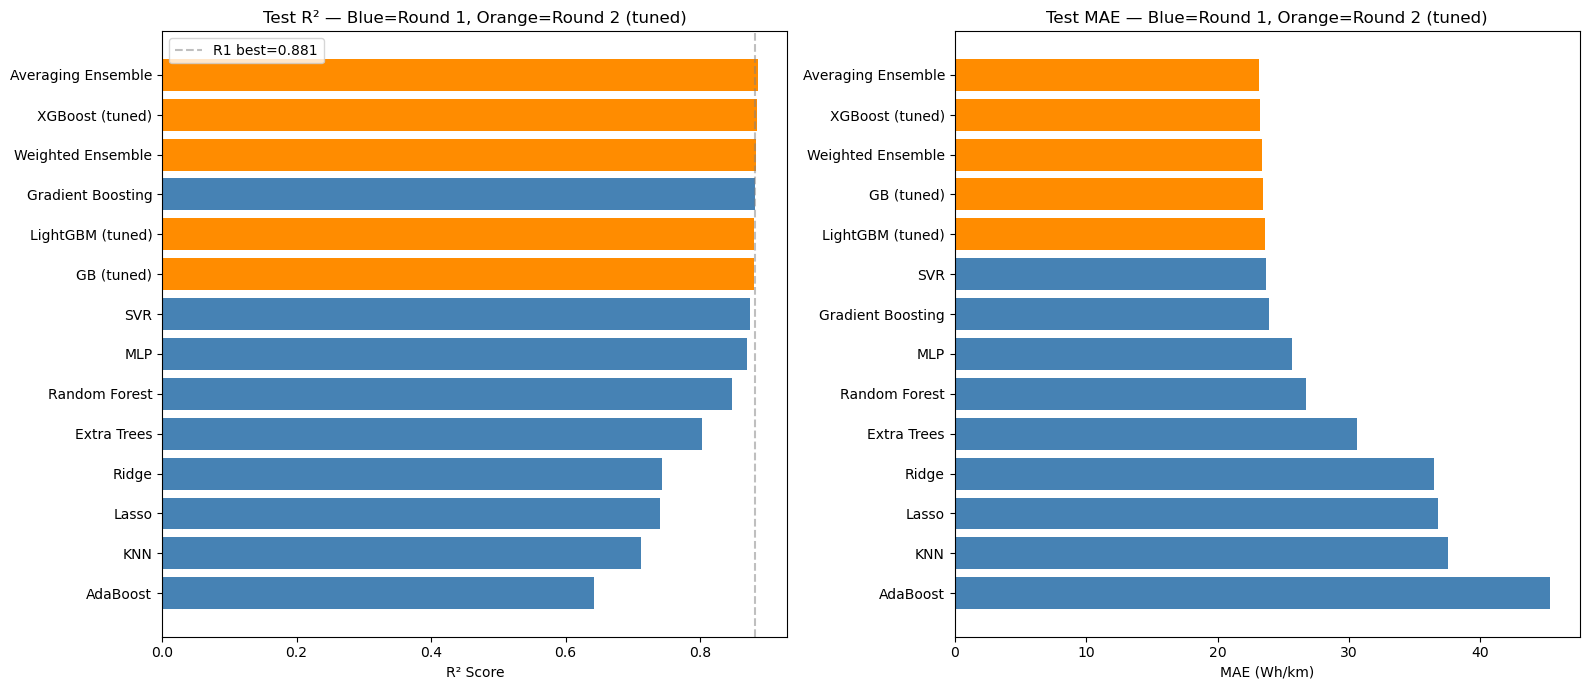

In [54]:
# --- Full comparison: Round 1 vs Round 2 ---
round2 = {}
r2_models = {
    'XGBoost (tuned)': (y_pred_xgb_train, y_pred_xgb_test),
    'LightGBM (tuned)': (y_pred_lgb_train, y_pred_lgb_test),
    'GB (tuned)': (y_pred_gbt_train, y_pred_gbt_test),
    'Weighted Ensemble': (y_pred_ens_train, y_pred_ens_test),
    'Averaging Ensemble': (y_pred_avg_train, y_pred_avg_test),
}

for name, (ytr, yte) in r2_models.items():
    tr_r2 = r2_score(y_train, ytr)
    te_r2 = r2_score(y_test, yte)
    round2[name] = {
        'Train R²': tr_r2,
        'Test R²': te_r2,
        'Test MAE': mean_absolute_error(y_test, yte),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, yte)),
        'Overfit': tr_r2 - te_r2,
    }

all_results = {**results, **round2}
all_df = pd.DataFrame(all_results).T.sort_values('Test R²', ascending=False)

print("=" * 90)
print("FULL BENCHMARK (60s windows, 23+ features, GroupKFold tuning)")
print("=" * 90)
print(all_df[['Test R²', 'Test MAE', 'Test RMSE', 'Overfit']].round(4).to_string())
print("=" * 90)

r1_best_r2 = results_df.iloc[0]['Test R²']
overall_best_name = all_df.index[0]
overall_best_r2 = all_df.iloc[0]['Test R²']
print(f"\nRound 1 best: {results_df.index[0]} (R²={r1_best_r2:.4f})")
print(f"Overall best:  {overall_best_name} (R²={overall_best_r2:.4f})")
delta = overall_best_r2 - r1_best_r2
print(f"Improvement: {'+' if delta>=0 else ''}{delta:.4f} R²")

# Update best_model for downstream cells
if overall_best_r2 > r1_best_r2:
    best_name = overall_best_name
    model_map = {
        'XGBoost (tuned)': xgb_best,
        'LightGBM (tuned)': lgb_best,
        'GB (tuned)': gb_tuned,
    }
    if best_name in model_map:
        best_model = model_map[best_name]
    predictions[best_name] = r2_models[best_name][1]
    print(f">>> Updated best_model to {best_name}")
else:
    best_name = results_df.index[0]

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sorted_all = all_df.sort_values('Test R²', ascending=True)
colors = ['steelblue' if n in results else 'darkorange' for n in sorted_all.index]
axes[0].barh(sorted_all.index, sorted_all['Test R²'], color=colors)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Test R² — Blue=Round 1, Orange=Round 2 (tuned)')
axes[0].axvline(r1_best_r2, color='gray', ls='--', alpha=0.5, label=f'R1 best={r1_best_r2:.3f}')
axes[0].legend()

sorted_mae = all_df.sort_values('Test MAE', ascending=False)
colors_mae = ['steelblue' if n in results else 'darkorange' for n in sorted_mae.index]
axes[1].barh(sorted_mae.index, sorted_mae['Test MAE'], color=colors_mae)
axes[1].set_xlabel('MAE (Wh/km)')
axes[1].set_title('Test MAE — Blue=Round 1, Orange=Round 2 (tuned)')
plt.tight_layout()
plt.show()

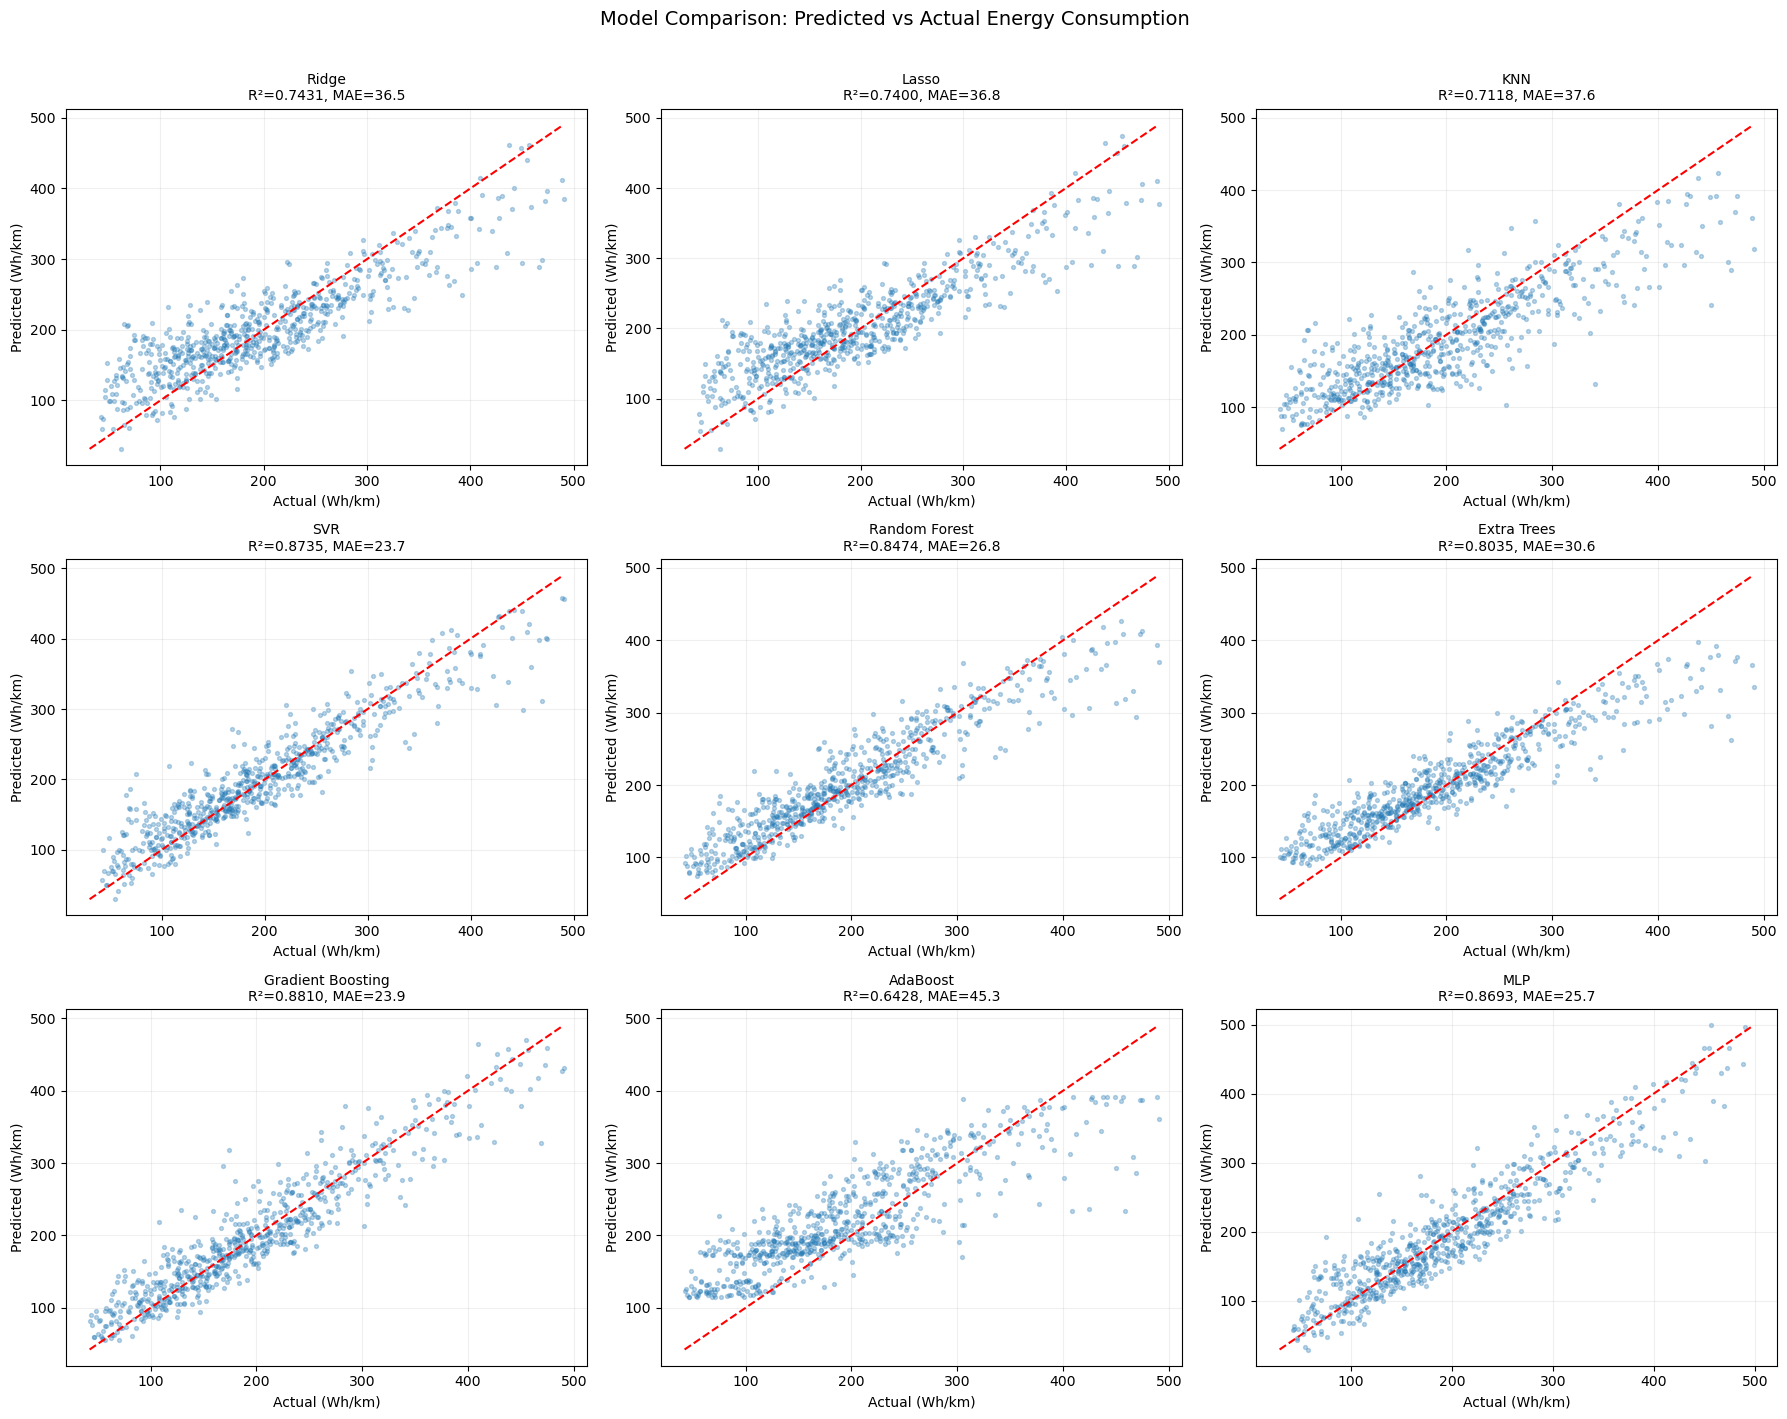

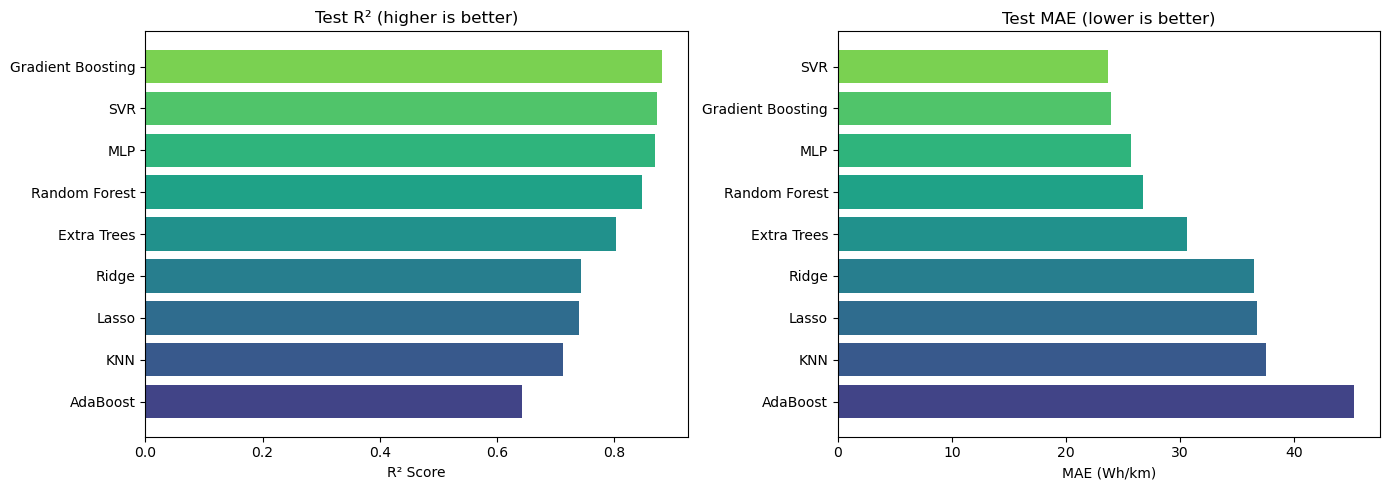

In [55]:
# Visual comparison of all models
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
model_names = list(results.keys())

for idx, name in enumerate(model_names):
    ax = axes[idx // 3, idx % 3]
    y_pred = predictions[name]
    r2 = results[name]['Test R²']
    mae = results[name]['Test MAE']
    
    ax.scatter(y_test, y_pred, alpha=0.3, s=8)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_title(f'{name}\nR²={r2:.4f}, MAE={mae:.1f}', fontsize=10)
    ax.set_xlabel('Actual (Wh/km)')
    ax.set_ylabel('Predicted (Wh/km)')
    ax.grid(True, alpha=0.2)

plt.suptitle('Model Comparison: Predicted vs Actual Energy Consumption', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sorted_results = results_df.sort_values('Test R²', ascending=True)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_results)))
axes[0].barh(sorted_results.index, sorted_results['Test R²'], color=colors)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Test R² (higher is better)')
axes[0].set_xlim(left=min(0, sorted_results['Test R²'].min()-0.05))

sorted_mae = results_df.sort_values('Test MAE', ascending=False)
axes[1].barh(sorted_mae.index, sorted_mae['Test MAE'], color=colors)
axes[1].set_xlabel('MAE (Wh/km)')
axes[1].set_title('Test MAE (lower is better)')

plt.tight_layout()
plt.show()

Best model: Gradient Boosting (R²=0.8810)


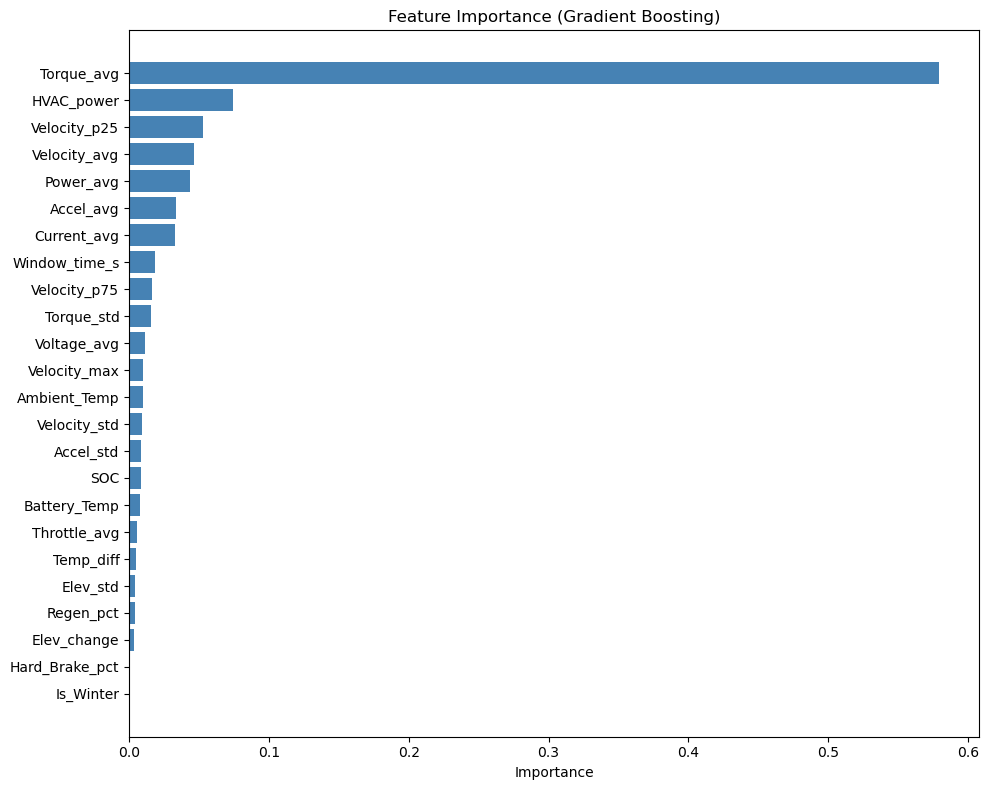


Top 5 features:
  Torque_avg: 0.5791
  HVAC_power: 0.0741
  Velocity_p25: 0.0530
  Velocity_avg: 0.0465
  Power_avg: 0.0435


In [56]:
# Feature importance for the best tree-based model
best_name = results_df.index[0]
print(f"Best model: {best_name} (R²={results[best_name]['Test R²']:.4f})")

# Get feature importance from the best tree-based model
tree_models = ['Random Forest', 'Extra Trees', 'Gradient Boosting']
best_tree = None
for name in results_df.index:
    if name in tree_models:
        best_tree = name
        break

if best_tree:
    model = models[best_tree]
    importances = model.feature_importances_
    fi = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
    fi = fi.sort_values('Importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(fi['Feature'], fi['Importance'], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importance ({best_tree})')
    plt.tight_layout()
    plt.show()
    
    print(f"\nTop 5 features:")
    for _, row in fi.nlargest(5, 'Importance').iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")

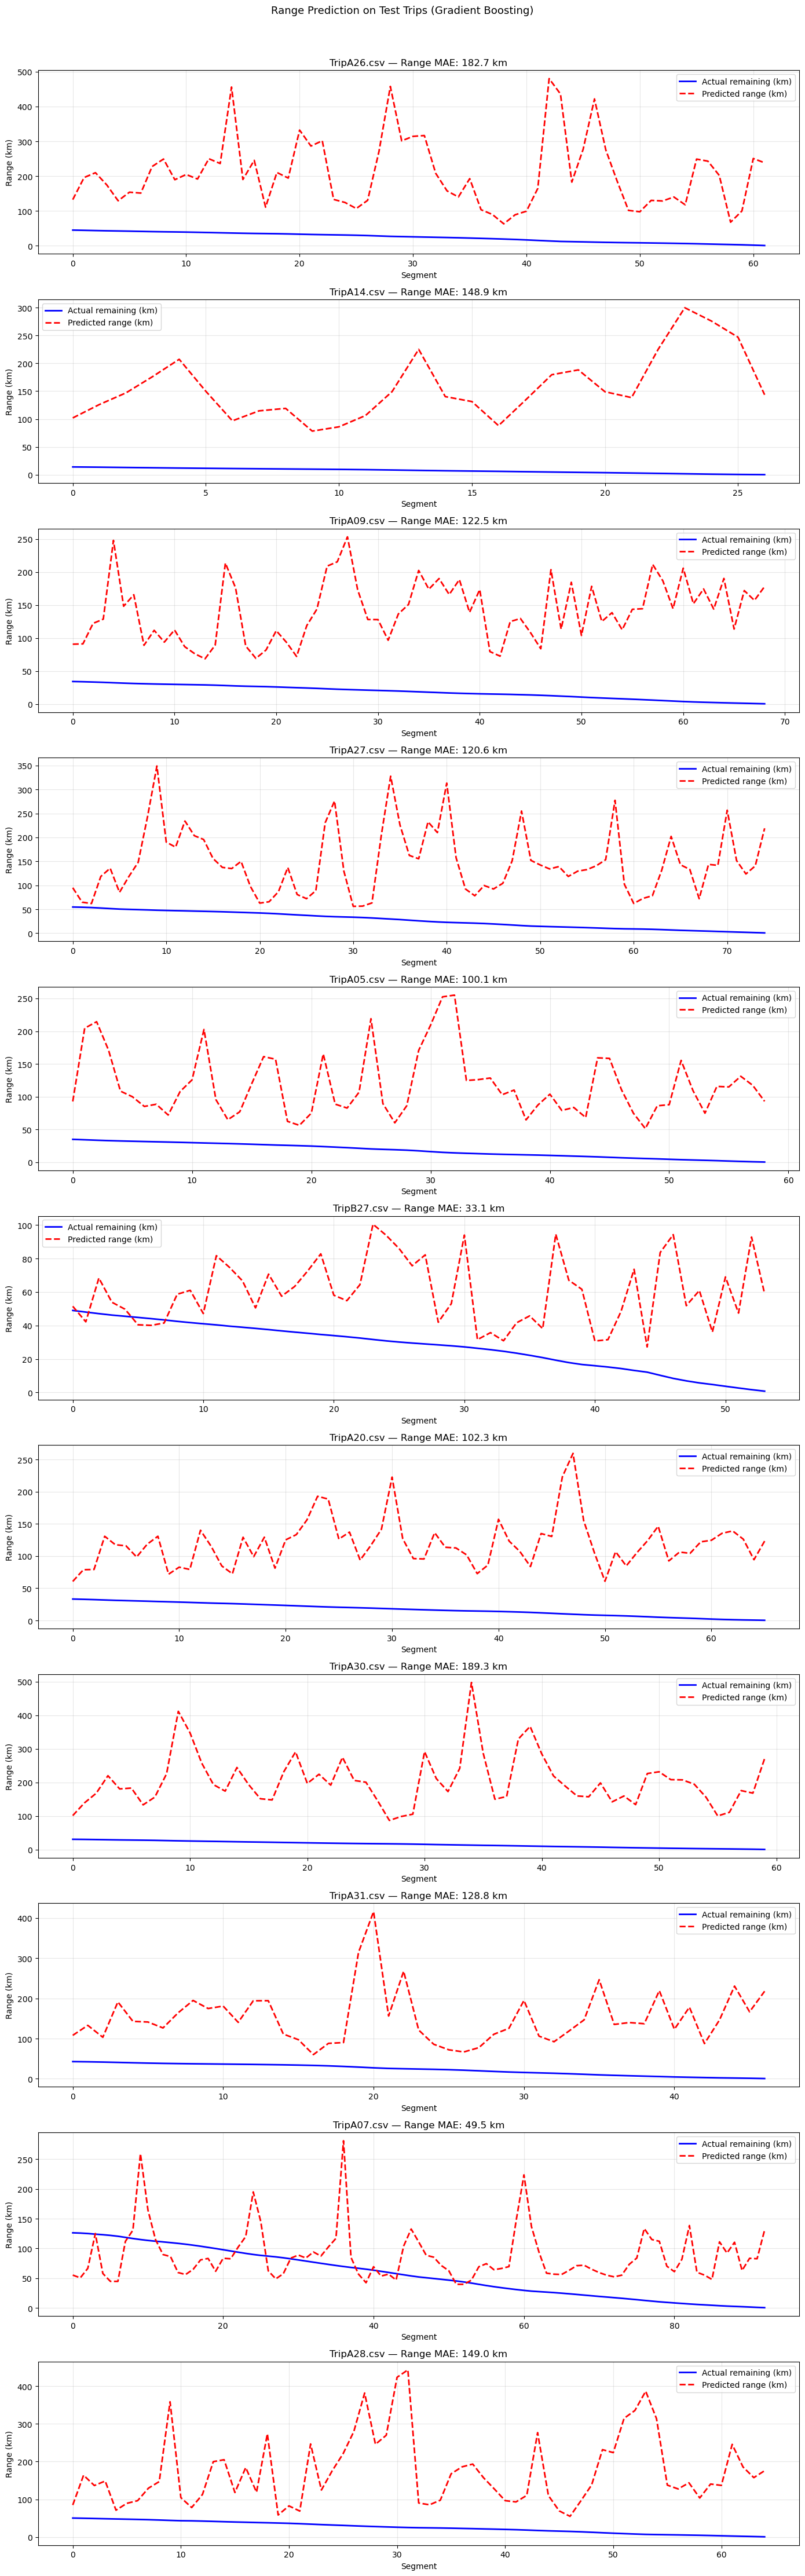

In [57]:
# Range prediction on test trips: simulate real-time range estimation
# At each segment, predict consumption → compute estimated remaining range
# Compare against actual remaining distance in the trip

best_model = models[best_name]

def predict_range(soc, consumption_wh_per_km):
    remaining_wh = (soc / 100.0) * BATTERY_CAPACITY_KWH * 1000
    return remaining_wh / consumption_wh_per_km

fig, axes = plt.subplots(len(test_trips), 1, figsize=(14, 4 * len(test_trips)), squeeze=False)

for t_idx, trip in enumerate(test_trips):
    trip_segs = test[test['Trip'] == trip].reset_index(drop=True)
    if len(trip_segs) < 3:
        continue
    
    X_trip = scaler.transform(trip_segs[feature_cols].values)
    pred_consumption = best_model.predict(X_trip)
    
    predicted_ranges = []
    actual_remaining = []
    
    # Compute actual total distance for the trip
    actual_distances = []
    for _, row in trip_segs.iterrows():
        actual_distances.append(row['Velocity_avg'] * WINDOW * 0.1 / 3600)  # approx km per segment
    total_trip_dist = sum(actual_distances)
    
    cumulative = 0
    for i in range(len(trip_segs)):
        soc = trip_segs.iloc[i]['SOC']
        pred_range = predict_range(soc, pred_consumption[i])
        predicted_ranges.append(pred_range)
        actual_remaining.append(total_trip_dist - cumulative)
        cumulative += actual_distances[i]
    
    ax = axes[t_idx, 0]
    x = range(len(predicted_ranges))
    ax.plot(x, actual_remaining, 'b-', linewidth=2, label='Actual remaining (km)')
    ax.plot(x, predicted_ranges, 'r--', linewidth=2, label='Predicted range (km)')
    
    mae = mean_absolute_error(actual_remaining, predicted_ranges)
    ax.set_title(f'{trip} — Range MAE: {mae:.1f} km')
    ax.set_xlabel('Segment')
    ax.set_ylabel('Range (km)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Range Prediction on Test Trips ({best_name})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [58]:
# Scenario-based range estimation (practical output)
# For different driving situations, estimate range left at various SOC levels
baseline = data_clean[feature_cols].median().to_dict()

scenarios = {
    'City (Summer, HVAC off)': {**baseline, 'Velocity_avg': 35, 'Velocity_std': 15,
        'Velocity_max': 60, 'Ambient_Temp': 22, 'Battery_Temp': 28, 'Is_Winter': 0, 'HVAC_power': 0},
    'City (Winter, Heater on)': {**baseline, 'Velocity_avg': 30, 'Velocity_std': 12,
        'Velocity_max': 55, 'Ambient_Temp': -5, 'Battery_Temp': 10, 'Is_Winter': 1, 'HVAC_power': 5000},
    'Highway (Summer)': {**baseline, 'Velocity_avg': 100, 'Velocity_std': 8,
        'Velocity_max': 130, 'Ambient_Temp': 25, 'Battery_Temp': 32, 'Is_Winter': 0, 'HVAC_power': 500},
    'Highway (Winter)': {**baseline, 'Velocity_avg': 95, 'Velocity_std': 10,
        'Velocity_max': 120, 'Ambient_Temp': 0, 'Battery_Temp': 15, 'Is_Winter': 1, 'HVAC_power': 4000},
    'Mixed/Suburban': {**baseline, 'Velocity_avg': 55, 'Velocity_std': 20,
        'Velocity_max': 80, 'Ambient_Temp': 18, 'Battery_Temp': 25, 'Is_Winter': 0, 'HVAC_power': 300},
}

soc_levels = [100, 80, 60, 40, 20]

print(f"{'Scenario':<30s}", end='')
for soc in soc_levels:
    print(f"  SOC={soc}%", end='')
print(f"  {'Wh/km':>8s}")
print("-" * 90)

for name, conds in scenarios.items():
    feats = pd.DataFrame([[conds.get(f, 0) for f in feature_cols]], columns=feature_cols)
    feats_s = scaler.transform(feats)
    consumption = best_model.predict(feats_s)[0]
    
    print(f"{name:<30s}", end='')
    for soc in soc_levels:
        remaining_wh = (soc / 100.0) * BATTERY_CAPACITY_KWH * 1000
        range_km = remaining_wh / consumption
        
        avg_v = conds.get('Velocity_avg', 50)
        time_h = range_km / avg_v
        print(f"  {range_km:5.0f}km", end='')
    print(f"  {consumption:7.1f}")

Scenario                        SOC=100%  SOC=80%  SOC=60%  SOC=40%  SOC=20%     Wh/km
------------------------------------------------------------------------------------------
City (Summer, HVAC off)           185km    148km    111km     74km     37km    178.3
City (Winter, Heater on)          123km     98km     74km     49km     25km    269.2
Highway (Summer)                  201km    161km    121km     80km     40km    164.0
Highway (Winter)                  139km    111km     83km     56km     28km    237.8
Mixed/Suburban                    197km    158km    118km     79km     39km    167.4


In [59]:
# Final summary — uses whichever model is overall best
print("=" * 70)
print("RANGE PREDICTION BENCHMARK SUMMARY")
print("=" * 70)
print(f"\nDataset: {len(data):,} segments from {data['Trip'].nunique()} trips")
print(f"Window: {WINDOW} samples (~{WINDOW//10}s), Stride: {STRIDE}")
print(f"Features: {len(feature_cols)}")
print(f"Train/Test split: {len(train_trips)}/{len(test_trips)} trips")
print(f"\nAll Models (by Test R²):")
for i, (name, row) in enumerate(all_df.iterrows(), 1):
    src = "R2" if name in round2 else "R1"
    marker = " ◀ BEST" if i == 1 else ""
    print(f"  {i:2d}. [{src}] {name:<22s}  R²={row['Test R²']:.4f}  "
          f"MAE={row['Test MAE']:.1f} Wh/km  "
          f"RMSE={row['Test RMSE']:.1f} Wh/km  "
          f"Overfit={row['Overfit']:.4f}{marker}")

best_row = all_df.iloc[0]
avg_consumption = y_test.mean()
print(f"\nBest model error as % of mean consumption: "
      f"{best_row['Test MAE']/avg_consumption*100:.1f}%")
print(f"Mean test consumption: {avg_consumption:.0f} Wh/km")
print(f"\nAt 100% SOC ({BATTERY_CAPACITY_KWH} kWh), predicted range:")
print(f"  Nominal: {BATTERY_CAPACITY_KWH*1000/avg_consumption:.0f} km")
print(f"  Error margin: ±{best_row['Test MAE']/avg_consumption * BATTERY_CAPACITY_KWH*1000/avg_consumption:.0f} km")
print("=" * 70)

RANGE PREDICTION BENCHMARK SUMMARY

Dataset: 2,571 segments from 42 trips
Window: 600 samples (~60s), Stride: 200
Features: 24
Train/Test split: 31/11 trips

All Models (by Test R²):
   1. [R2] Averaging Ensemble      R²=0.8857  MAE=23.1 Wh/km  RMSE=31.2 Wh/km  Overfit=-0.0765 ◀ BEST
   2. [R2] XGBoost (tuned)         R²=0.8853  MAE=23.2 Wh/km  RMSE=31.3 Wh/km  Overfit=0.0560
   3. [R2] Weighted Ensemble       R²=0.8836  MAE=23.3 Wh/km  RMSE=31.5 Wh/km  Overfit=-0.0735
   4. [R1] Gradient Boosting       R²=0.8810  MAE=23.9 Wh/km  RMSE=31.9 Wh/km  Overfit=0.1039
   5. [R2] LightGBM (tuned)        R²=0.8807  MAE=23.6 Wh/km  RMSE=31.9 Wh/km  Overfit=0.0688
   6. [R2] GB (tuned)              R²=0.8801  MAE=23.5 Wh/km  RMSE=32.0 Wh/km  Overfit=0.1080
   7. [R1] SVR                     R²=0.8735  MAE=23.7 Wh/km  RMSE=32.8 Wh/km  Overfit=0.0274
   8. [R1] MLP                     R²=0.8693  MAE=25.7 Wh/km  RMSE=33.4 Wh/km  Overfit=0.0430
   9. [R1] Random Forest           R²=0.8474  MAE=26.8 W